In [14]:
import pandas as pd
import plotly.express as px
import geopandas as gpd
import matplotlib.pyplot as plt


In [15]:
df = pd.read_csv("dados.csv",sep='\t')
print(df.head())

  Estado  Antes  Depois
0     AC   33.9    33.7
1     AL   32.1    31.7
2     AM   33.5    33.1
3     AP   35.6    36.7
4     BA   36.5    36.0


In [10]:
siglas_geojson = {
    f["properties"]["sigla"]
    for f in geojson["features"]
}

print(set(df["Estado"]) - siglas_geojson)

set()


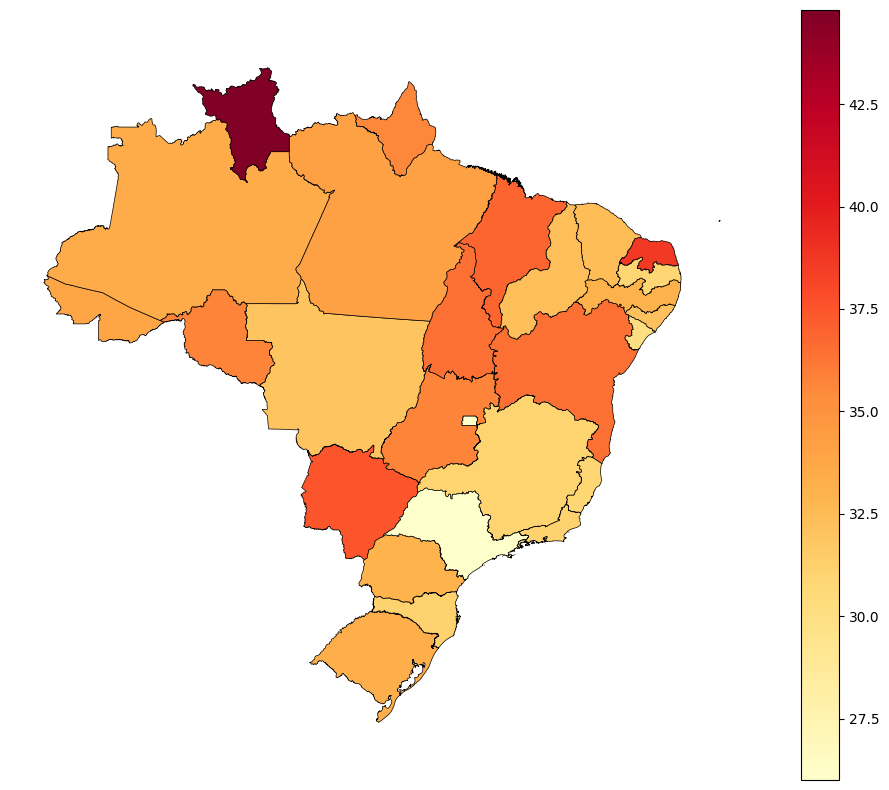

In [16]:
estados = gpd.read_file(
    "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
)

dados = pd.read_csv("dados.csv", sep="\t")

mapa = estados.merge(
    dados,
    left_on="sigla",
    right_on="Estado"
)

fig, ax = plt.subplots(figsize=(12,10))

mapa.plot(
    column="Antes",
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    ax=ax
)

ax.set_axis_off()

plt.savefig("mapa_brasil.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
fig = px.choropleth(
    df,
    locations='Estado',
    locationmode='geojson-id',
    color='Antes',
    scope='south america',
    color_continuous_scale='Reds'
)

fig.show()

In [9]:
import requests

url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
geojson = requests.get(url).json()

print(geojson["features"][0]["properties"])

{'id': 1, 'name': 'Acre', 'sigla': 'AC', 'regiao_id': '3', 'codigo_ibg': '12', 'cartodb_id': 1, 'created_at': '2015-02-09T16:46:01Z', 'updated_at': '2015-02-09T16:46:01Z'}
